## Here are 10 analytical questions involving the Titanic dataset that test various data analysis skills – from basic exploration to advanced feature engineering. Each requires hands-on pandas implementation:
1. Survival Rate by Passenger Class
How does survival rate differ between passenger classes (1st, 2nd, 3rd)?
Requires: groupby(), mean(), and handling categorical data.
Insight: Reveals historical class-based survival patterns.
2. Gender Bias in Survival
Calculate survival rates for males vs. females, then compare to overall survival rate.
Requires: groupby() on Sex, agg(), and conditional logic.
Insight: Highlights the "women and children first" protocol.
3. Missing Cabin Class Analysis
How many passengers without a cabin (Cabin = NaN) survived? Compare this to passengers with cabins.
Requires: Handling missing values (dropna()/fillna()), and groupby() with count().
Insight: Identifies data quality issues and survival trends.
4. Family Size Impact
Create a "Family Size" feature (SibSp + Parch + 1) and analyze its correlation with survival.
Requires: Feature engineering with apply(), corr(), and hist() visualization.
Insight: Reveals how family structure affected survival.
5. Age Distribution of Survivors vs. Non-Survivors
Generate age distributions using histograms for survivors and non-survivors. How does age distribution differ?
Requires: seaborn plotting, bins, and df['Age'].plot().
Insight: Shows how young children had higher survival rates.
6. Embarkation Port Analysis
Calculate survival rates per port (C, Q, S). Which port had the highest survival rate?
Requires: groupby() on Embarked, and handling missing values in Embarked (common in Titanic data).
Insight: Reveals strategic boarding locations.
7. Ticket Class vs. Survival
Extract ticket class from Ticket (e.g., 'A/5' → 'A') and analyze survival rates per ticket class.
Requires: String manipulation with str[0], groupby(), and pivot tables.
Insight: Uncovering hidden social hierarchies.
8. Missing Fare Handling
How many passengers had missing Fare values? Calculate the median fare for each passenger class.
Requires: fillna() with median, groupby(), and transform().
Insight: Demonstrates proper imputation techniques.
9. Correlation Matrix Analysis
Compute the correlation between Age, Fare, and Survived. What features are most correlated with survival?
Requires: df.corr(), and visualizing with heatmap().
Insight: Identifies actionable features for ML models.
10. Advanced Feature Engineering
*Create a "Family Size" feature (SibSp + Parch) and merge it with Survived to calculate survival rates for:
Families of size 1 vs. 2+
Solo travelers (size = 0)*
Requires: Advanced groupby(), lambda functions, and conditional aggregation.
Insight: Reveals how family size influenced survival beyond class/age.
Why these questions matter for data science:
Real-world relevance – Answers connect to historical events (e.g., gender bias).
Technical depth – Covers missing values, feature engineering, and visualization.
Critical thinking – Forces interpretation beyond raw numbers (e.g., "Why does class matter?").
Data integrity – Tests handling of messy data (e.g., missing cabin numbers).

Pro Tip: Use df.describe() and df.isnull().sum() first to understand data structure before solving these!
Example: "How many missing values in Cabin? How does that affect analysis?"
These questions bridge basic data analysis with practical insights – exactly what you'd face in a real-world project using the Titanic dataset.


In [1]:
from google.colab import files
uploaded= files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Survival Rate by Passenger Class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Survival Rate by Gender:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Overall Survival Rate: 0.3838

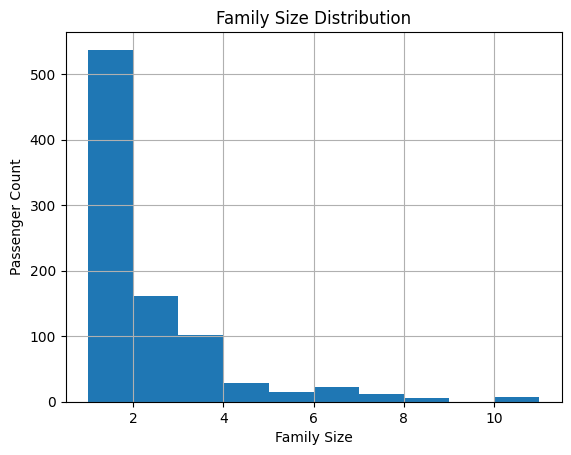

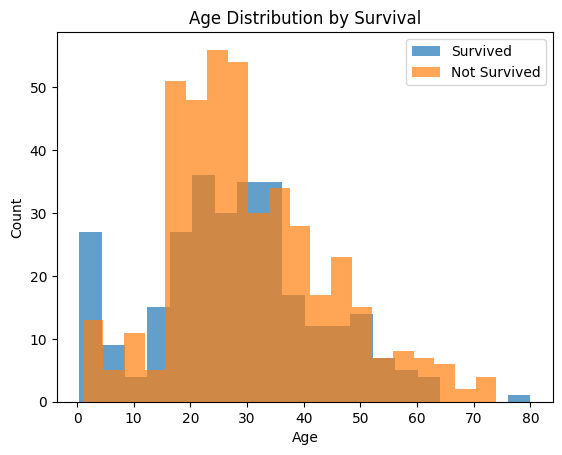


Survival Rate by Embarkation Port:
Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64

Survival Rate by Ticket Class:
Ticket_Class
1    0.630137
2    0.464481
3    0.239203
4    0.200000
5    0.000000
6    0.166667
7    0.111111
8    0.000000
9    1.000000
A    0.068966
C    0.340426
F    0.571429
L    0.250000
P    0.646154
S    0.323077
W    0.153846
Name: Survived, dtype: float64

Missing Fare Values: 0

Correlation Matrix:
          Survived       Age      Fare
Survived  1.000000 -0.077221  0.257307
Age      -0.077221  1.000000  0.096067
Fare      0.257307  0.096067  1.000000


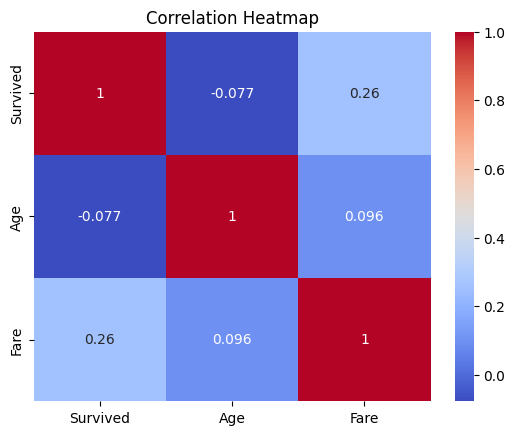


Survival Rate by Family Group:
FamilyGroup
Large Family    0.466321
Small Family    0.552795
Solo            0.303538
Name: Survived, dtype: float64


In [2]:

# TITANIC DATA ANALYSIS – STEP BY STEP


# STEP 0: Import required libraries
# pandas → data manipulation & analysis
# matplotlib & seaborn → data visualization

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# STEP 1: Load the Titanic dataset
# We load the CSV file into a DataFrame
# A DataFrame is a table-like structure (rows & columns)

df = pd.read_csv("/content/Titanic-Dataset.csv")
# STEP 2: Understand the dataset (MOST IMPORTANT STEP)
# 2.1 View first 5 rows
# This helps us understand column names and sample values
df.head()

# 2.2 Dataset structure
# Shows column names, data types, and missing values
df.info()

# 2.3 Check missing values column-wise
# Real-world datasets are messy → this is mandatory
df.isnull().sum()

# 2.4 Statistical summary of numerical columns
# Gives mean, median, min, max, etc.
df.describe()
# QUESTION 1: Survival Rate by Passenger Class
# Group passengers by class (1st, 2nd, 3rd)
# Take the mean of Survived column
# Mean works because Survived = 1 (yes), 0 (no)

survival_by_class = df.groupby("Pclass")["Survived"].mean()
print("\nSurvival Rate by Passenger Class:")
print(survival_by_class)

# QUESTION 2: Gender Bias in Survival
# Survival rate by gender
survival_by_gender = df.groupby("Sex")["Survived"].mean()
print("\nSurvival Rate by Gender:")
print(survival_by_gender)

# Overall survival rate
overall_survival = df["Survived"].mean()
print("\nOverall Survival Rate:", overall_survival)

# QUESTION 3: Cabin Availability Analysis
# Create a new feature:
# True → passenger has cabin info
# False → cabin info missing (mostly lower class)

df["Has_Cabin"] = df["Cabin"].notnull()

# Compare survival rates
cabin_survival = df.groupby("Has_Cabin")["Survived"].mean()
print("\nSurvival Based on Cabin Availability:")
print(cabin_survival)

# QUESTION 4: Family Size Impact
# Feature engineering:
# FamilySize = siblings/spouse + parents/children + self

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Correlation with survival
family_corr = df["FamilySize"].corr(df["Survived"])
print("\nCorrelation between Family Size and Survival:", family_corr)

# Visualization
df["FamilySize"].hist(bins=10)
plt.xlabel("Family Size")
plt.ylabel("Passenger Count")
plt.title("Family Size Distribution")
plt.show()

# QUESTION 5: Age Distribution – Survivors vs Non-Survivors
# Separate survived and not survived passengers
survived = df[df["Survived"] == 1]
not_survived = df[df["Survived"] == 0]
# Plot age distributions
survived["Age"].plot(kind="hist", bins=20, alpha=0.7, label="Survived")
not_survived["Age"].plot(kind="hist", bins=20, alpha=0.7, label="Not Survived")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()
plt.title("Age Distribution by Survival")
plt.show()


# QUESTION 6: Embarkation Port Analysis

# Fill missing Embarked values with mode (most common value)
# We avoid inplace=True to be future-proof

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Survival rate per port
embarked_survival = df.groupby("Embarked")["Survived"].mean()
print("\nSurvival Rate by Embarkation Port:")
print(embarked_survival)

# QUESTION 7: Ticket Class vs Survival


# Extract first character from Ticket (ticket prefix)
df["Ticket_Class"] = df["Ticket"].str[0]

ticket_survival = df.groupby("Ticket_Class")["Survived"].mean()
print("\nSurvival Rate by Ticket Class:")
print(ticket_survival)


# QUESTION 8: Missing Fare Handling


# Check missing Fare values
print("\nMissing Fare Values:", df["Fare"].isnull().sum())

# Fill missing Fare using median Fare of passenger class
df["Fare"] = df.groupby("Pclass")["Fare"].transform(
    lambda x: x.fillna(x.median())
)

# QUESTION 9: Correlation Matrix Analysis

# Select numerical columns
corr_matrix = df[["Survived", "Age", "Fare"]].corr()
print("\nCorrelation Matrix:")
print(corr_matrix)

# Heatmap visualization
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# QUESTION 10: Advanced Family Size Analysi

# Family size without counting self
df["FamilySize2"] = df["SibSp"] + df["Parch"]

# Categorize family types
df["FamilyGroup"] = df["FamilySize2"].apply(
    lambda x: "Solo" if x == 0 else "Small Family" if x == 1 else "Large Family"
)

family_group_survival = df.groupby("FamilyGroup")["Survived"].mean()
print("\nSurvival Rate by Family Group:")
print(family_group_survival)


